# EVM Verification

Computes the RMS EVM at the TX (after the PA) and after the full chain. Constellations are saved/shown for visual inspection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.units import dbm_to_w, w_to_dbm


from rfmodel.plot_utils import plot_constellation

from tx_setup import build_test_setup

In [2]:
setup = build_test_setup(input_pwr_dbm=-25.0, enable_ofdm_weighting=True)

pipe                = setup.pipe
qam                 = setup.qam
ofdm                = setup.ofdm
qam_symbols         = setup.qam_symbols
sig_ofdm_normalized = setup.sig_ofdm_normalized

## TX EVM — after PA

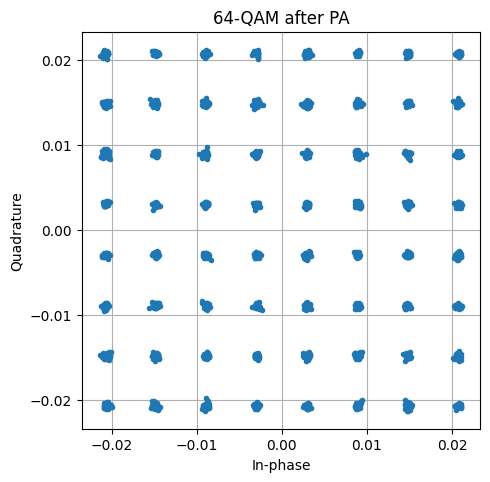

TX EVM (RMS): 1.38 %
TX EVM (RMS): -37.23 dB


In [3]:
# Measure EVM at the PA output (TX-only reference plane).
_, taps = pipe.run(sig_ofdm_normalized, taps=['PA_TX'])
sig_pa_demod = ofdm.demodulate(taps['PA_TX'])

plot_constellation(sig_pa_demod.x, title='64-QAM after PA', fig_scale=2)

# Power-normalise the RX symbols against the TX reference before computing EVM
rx      = sig_pa_demod.x
tx      = qam_symbols
rx_norm = rx * np.sqrt(np.mean(np.abs(tx)**2) / np.mean(np.abs(rx)**2))

error   = rx_norm - tx
evm_rms = np.sqrt(np.mean(np.abs(error)**2) / np.mean(np.abs(tx)**2)) * 100

print(f'TX EVM (RMS): {evm_rms:.2f} %')
print(f'TX EVM (RMS): {20 * np.log10(evm_rms / 100):.2f} dB')

## Full-chain EVM

RX input power (LNA input): -53.31 dBm


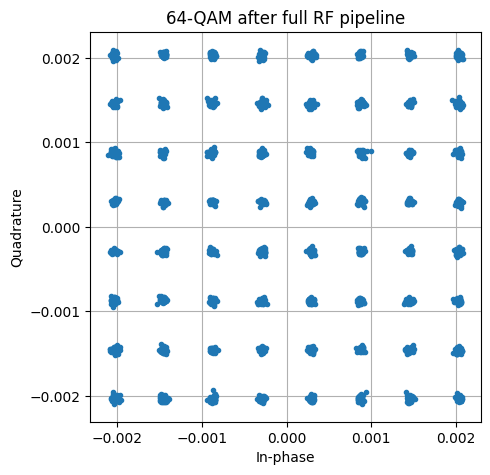

Full-chain EVM (RMS): 1.60 %
Full-chain EVM (RMS): -35.91 dB


In [4]:
# Full TX → channel → RX EVM at the receiver demodulator output.
sig_out, taps = pipe.run(sig_ofdm_normalized, taps=['PathLoss'])
sig_demod     = ofdm.demodulate(sig_out)

# RX input power (after path loss, before AWGN) — sets the LNA-input plane
rx_input_pwr_dbm = w_to_dbm(np.mean(np.abs(taps['PathLoss'].x) ** 2))
print(f'RX input power (LNA input): {rx_input_pwr_dbm:.2f} dBm')

plot_constellation(sig_demod.x, title='64-QAM after full RF pipeline', fig_scale=2)

rx      = sig_demod.x
tx      = qam_symbols
rx_norm = rx * np.sqrt(np.mean(np.abs(tx)**2) / np.mean(np.abs(rx)**2))

error   = rx_norm - tx
evm_rms = np.sqrt(np.mean(np.abs(error)**2) / np.mean(np.abs(tx)**2)) * 100

print(f'Full-chain EVM (RMS): {evm_rms:.2f} %')
print(f'Full-chain EVM (RMS): {20 * np.log10(evm_rms / 100):.2f} dB')

## TX EVM vs PLL Parameters

2-D sweep over **VCO phase noise at 1 MHz offset** and **PLL loop bandwidth** to
show how each drives TX EVM.

The TX EVM is measured at the PA output (same reference plane as the TX EVM cell
above) so the result is independent of the RX chain.  `N_avg` independent
phase-noise realisations are averaged per grid point to reduce Monte-Carlo variance.

> **Note on the phase-noise model.**  The PLL object caches
> `alpha = 10^(PN/10) × f_offset²` at construction; changing `params.pll.VCO_Phase_Noise_dBc`
> after construction has no effect.  The sweep therefore sets `pll.alpha` directly.
> The loop bandwidth `f_L` **is** read live from `pll.p.f_L` each call, so it can
> be updated in place.

Running 9 × 7 grid, 3 avg → 189 pipeline runs
  PN = -130 dBc/Hz done  (EVM range: -37.6 – -37.6 dB)
  PN = -124 dBc/Hz done  (EVM range: -37.6 – -37.6 dB)
  PN = -119 dBc/Hz done  (EVM range: -37.6 – -37.3 dB)
  PN = -113 dBc/Hz done  (EVM range: -37.6 – -36.5 dB)
  PN = -108 dBc/Hz done  (EVM range: -37.6 – -34.7 dB)
  PN = -102 dBc/Hz done  (EVM range: -37.4 – -30.7 dB)
  PN = -96 dBc/Hz done  (EVM range: -36.7 – -26.0 dB)
  PN = -91 dBc/Hz done  (EVM range: -34.8 – -20.4 dB)
  PN = -85 dBc/Hz done  (EVM range: -31.3 – -15.2 dB)
Sweep complete — pipeline restored.


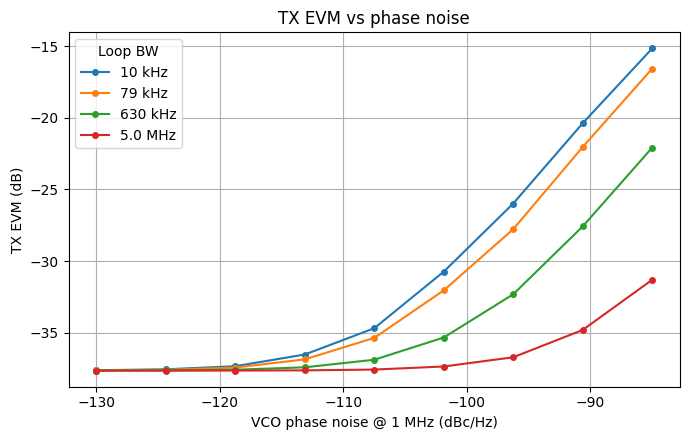

In [5]:
# 2-D sweep: TX EVM vs (VCO phase noise @ 1 MHz, loop bandwidth).

pn_sweep_dbchz = np.linspace(-130, -85, 9)                     # PN @ 1 MHz [dBc/Hz]
lb_sweep_hz    = np.logspace(np.log10(10e3), np.log10(5e6), 7) # loop bandwidth [Hz]
N_avg          = 3    # realisations per point (raise for smoother curves)

mixer_tx = pipe.get('mixer_and_pll_TX')
pll      = mixer_tx.pll

alpha_orig = pll.alpha
fl_orig    = pll.p.f_L

n_total = len(pn_sweep_dbchz) * len(lb_sweep_hz) * N_avg
print(f"Running {len(pn_sweep_dbchz)} × {len(lb_sweep_hz)} grid, {N_avg} avg → {n_total} pipeline runs")

evm_grid_db = np.zeros((len(lb_sweep_hz), len(pn_sweep_dbchz)))

for j, pn in enumerate(pn_sweep_dbchz):
    pll.alpha = 10.0 ** (pn / 10.0) * (1e6) ** 2     # set PN directly (see note above)

    for i, lb in enumerate(lb_sweep_hz):
        pll.p.f_L = lb

        evm_runs = []
        for _ in range(N_avg):
            _, taps = pipe.run(sig_ofdm_normalized, taps=['PA_TX'])
            rx      = ofdm.demodulate(taps['PA_TX']).x
            tx      = qam_symbols
            rx_norm = rx * np.sqrt(np.mean(np.abs(tx)**2) / np.mean(np.abs(rx)**2))
            error   = rx_norm - tx
            evm_pct = np.sqrt(np.mean(np.abs(error)**2) / np.mean(np.abs(tx)**2)) * 100
            evm_runs.append(20 * np.log10(evm_pct / 100))
        evm_grid_db[i, j] = np.mean(evm_runs)

    print(f"  PN = {pn:.0f} dBc/Hz done  "
          f"(EVM range: {evm_grid_db[:, j].min():.1f} – {evm_grid_db[:, j].max():.1f} dB)")

pll.alpha = alpha_orig
pll.p.f_L = fl_orig
print("Sweep complete — pipeline restored.")

# Pick 4 representative loop bandwidths for the line plot
lb_kHz = lb_sweep_hz / 1e3
sel    = np.round(np.linspace(0, len(lb_sweep_hz) - 1, 4)).astype(int)

plt.figure(figsize=(7, 4.5))
for i in sel:
    lbl = f'{lb_kHz[i]:.0f} kHz' if lb_kHz[i] < 1000 else f'{lb_kHz[i]/1e3:.1f} MHz'
    plt.plot(pn_sweep_dbchz, evm_grid_db[i, :], 'o-', markersize=4, label=lbl)
plt.xlabel('VCO phase noise @ 1 MHz (dBc/Hz)')
plt.ylabel('TX EVM (dB)')
plt.title('TX EVM vs phase noise')
plt.grid(True)
plt.legend(title='Loop BW', loc='upper left')
plt.tight_layout()
plt.show()

## Full-Chain EVM vs I/Q Imbalance

Sweeps **amplitude imbalance** (Q-branch gain relative to I, in dB) and **phase imbalance**
(quadrature phase error in degrees) and reports the resulting full-chain RMS EVM.

The standard complex-baseband I/Q imbalance model is:

$$y = K_1\, x + K_2\, x^*, \qquad
K_1 = \frac{1 + \alpha\, e^{\,j\theta}}{2}, \quad
K_2 = \frac{1 - \alpha\, e^{-j\theta}}{2}$$

where $\alpha = 10^{\varepsilon/20}$ (Q-to-I amplitude ratio, linear) and $\theta$ is the
phase error in radians.  At $\varepsilon = 0,\,\theta = 0$: $K_1 = 1$, $K_2 = 0$ — no distortion.

The imbalance is applied to the RX output signal (representing ADC / baseband I/Q mismatch).
Because the operation is **deterministic** the pipeline runs only **once**; the same output
signal is re-used for every grid point, so the result is free of noise-realisation variance.

Baseline EVM (no imbalance): -36.00 dB


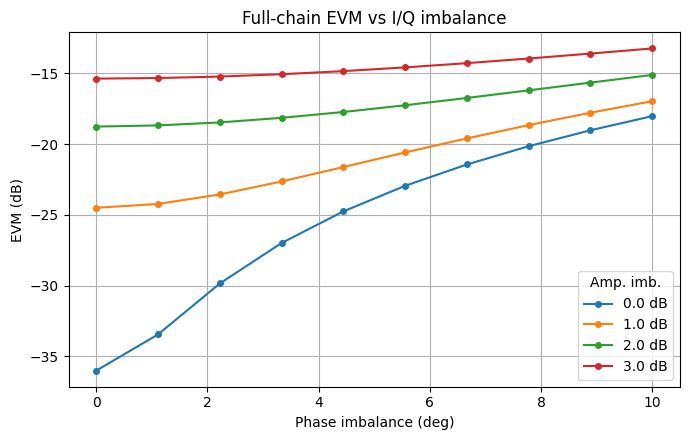

In [6]:
def apply_iq_imbalance(x, amp_imb_db, phase_imb_deg):
    """Apply I/Q amplitude and phase imbalance to a complex baseband signal.
        y  = K1·x + K2·conj(x)
        K1 = (1 + α·exp( jθ)) / 2,  K2 = (1 - α·exp(-jθ)) / 2
        α  = 10^(amp_imb_db/20),    θ  = phase_imb_deg in radians
    """
    alpha = 10.0 ** (amp_imb_db / 20.0)
    theta = np.deg2rad(phase_imb_deg)
    K1    = 0.5 * (1.0 + alpha * np.exp( 1j * theta))
    K2    = 0.5 * (1.0 - alpha * np.exp(-1j * theta))
    return K1 * x + K2 * np.conj(x)


amp_sweep_db    = np.linspace(0.0, 3.0, 10)   # Q-branch amplitude imbalance [dB]
phase_sweep_deg = np.linspace(0.0, 10.0, 10)  # quadrature phase error [deg]

# Run the full chain once — imbalance is deterministic so we re-use the output
sig_iq_out, _ = pipe.run(sig_ofdm_normalized)

evm_iq_grid_db = np.zeros((len(phase_sweep_deg), len(amp_sweep_db)))

for j, amp in enumerate(amp_sweep_db):
    for i, phi in enumerate(phase_sweep_deg):
        x_iq    = apply_iq_imbalance(sig_iq_out.x, amp, phi)
        rx      = ofdm.demodulate(sig_iq_out.copy_with(x=x_iq)).x
        tx      = qam_symbols
        rx_norm = rx * np.sqrt(np.mean(np.abs(tx)**2) / np.mean(np.abs(rx)**2))
        error   = rx_norm - tx
        evm_pct = np.sqrt(np.mean(np.abs(error)**2) / np.mean(np.abs(tx)**2)) * 100
        evm_iq_grid_db[i, j] = 20 * np.log10(evm_pct / 100)

print(f"Baseline EVM (no imbalance): {evm_iq_grid_db[0, 0]:.2f} dB")

# Show EVM vs phase error for 4 representative amplitude-imbalance values
sel = np.round(np.linspace(0, len(amp_sweep_db) - 1, 4)).astype(int)

plt.figure(figsize=(7, 4.5))
for j in sel:
    plt.plot(phase_sweep_deg, evm_iq_grid_db[:, j], 'o-', markersize=4,
             label=f'{amp_sweep_db[j]:.1f} dB')
plt.xlabel('Phase imbalance (deg)')
plt.ylabel('EVM (dB)')
plt.title('Full-chain EVM vs I/Q imbalance')
plt.grid(True)
plt.legend(title='Amp. imb.', loc='lower right')
plt.tight_layout()
plt.show()

## I/Q Imbalance — Single-Point EVM Penalty

Set the amplitude and phase imbalance values below to see the EVM penalty relative to the balanced (ideal) case.

In [7]:
# ── User inputs ───────────────────────────────────────────────────────────────
amp_imb_db    = 0.2   # Q-branch amplitude imbalance [dB]
phase_imb_deg = 1.5   # quadrature phase error [deg]

# ── Baseline (no imbalance) ───────────────────────────────────────────────────
def _evm_db(sig_out, qam_symbols, ofdm):
    rx      = ofdm.demodulate(sig_out).x
    tx      = qam_symbols
    rx_norm = rx * np.sqrt(np.mean(np.abs(tx) ** 2) / np.mean(np.abs(rx) ** 2))
    error   = rx_norm - tx
    evm_pct = np.sqrt(np.mean(np.abs(error) ** 2) / np.mean(np.abs(tx) ** 2)) * 100
    return 20 * np.log10(evm_pct / 100)

sig_iq_ref, _ = pipe.run(sig_ofdm_normalized)

evm_baseline_db = _evm_db(sig_iq_ref, qam_symbols, ofdm)

# ── With imbalance ────────────────────────────────────────────────────────────
x_iq        = apply_iq_imbalance(sig_iq_ref.x, amp_imb_db, phase_imb_deg)
sig_iq_imb  = sig_iq_ref.copy_with(x=x_iq)
evm_imb_db  = _evm_db(sig_iq_imb, qam_symbols, ofdm)

penalty_db  = evm_imb_db - evm_baseline_db

print(f"Amplitude imbalance : {amp_imb_db:.2f} dB")
print(f"Phase imbalance     : {phase_imb_deg:.2f} deg")
print()
print(f"Baseline EVM        : {evm_baseline_db:.2f} dB")
print(f"EVM with imbalance  : {evm_imb_db:.2f} dB")
print(f"EVM penalty         : {penalty_db:+.2f} dB")

Amplitude imbalance : 0.20 dB
Phase imbalance     : 1.50 deg

Baseline EVM        : -36.05 dB
EVM with imbalance  : -31.18 dB
EVM penalty         : +4.87 dB
